In [ ]:
# Import necessary libraries for date and time manipulation, timezone handling, and displaying formatted text in a notebook
from datetime import datetime
from pytz import timezone
from IPython.display import display, Markdown, HTML

# Display the first statement in green and bold
display(HTML("<p style='color:green; font-weight:bold;'>This is the first cell. Initialization and setup are done below:</p>"))

# Set IST timezone (Indian Standard Time)
ist = timezone('Asia/Kolkata')

# Get the current time in IST
current_time_ist = datetime.now(ist).strftime('%Y-%m-%d %H:%M:%S')

# Display the current IST time in bold (default color)
display(Markdown(f'**Current IST Time: {current_time_ist}**'))


You must have heard some advertisements regarding medical insurance that promises to help financially in case of any medical emergency. One who purchases this type of insurance has to pay premiums monthly and this premium amount varies vastly depending upon various factors.

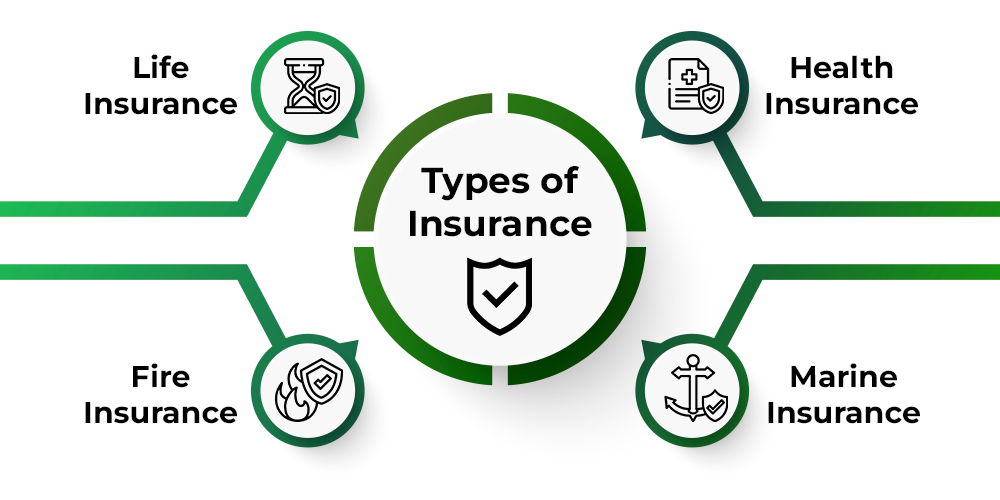

# Medical Insurance Price Prediction using Machine Learning in Python

In this article, we will try to extract some insights from a dataset that contains details about the background of a person who is purchasing medical insurance along with what amount of premium is charged to those individuals as well using Machine Learning in Python.

# Importing Libraries and Dataset

Python libraries make it very easy for us to handle the data and perform typical and complex tasks with a single line of code.

**1.	Pandas –** This library helps to load the data frame in a 2D array format and has multiple functions to perform analysis tasks in one go.

**2.	Numpy –** Numpy arrays are very fast and can perform large computations in a very short time.

**3.	Matplotlib/Seaborn –** This library is used to draw visualizations.



In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as pt
import warnings
warnings.filterwarnings("ignore")


Now let’s use the panda’s data frame to load the dataset and look at the first five rows of it.

In [ ]:
df=pd.read_csv("https://raw.githubusercontent.com/adiag321/Medical-Insurance-Cost-Prediction/main/data/insurance.csv")



In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


Now, we can observe the data and its shape(rows x columns)

This dataset contains 1338 data points with 6 independent features and 1 target feature(charges).

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


From the above, we can see that the dataset contains 2 columns with float values 3 with categorical values and the rest contains integer values.

In [ ]:
df.describe()


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


We can look at the descriptive statistical measures of the continuous data available in the dataset.

https://www.geeksforgeeks.org/descriptive-statistic/

# Exploratory Data Analysis

1.	EDA is an approach to analyzing the data using visual techniques.

2.	It is used to discover trends, and patterns, or to check assumptions with the help of statistical summaries and graphical representations.

3.	While performing the EDA of this dataset we will try to look at what is the relation between the independent features that is how one affects the other.



In [ ]:
df.isnull().sum()


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

So, here we can conclude that there are no null values in the dataset given.

In [ ]:
import matplotlib.pyplot as plt

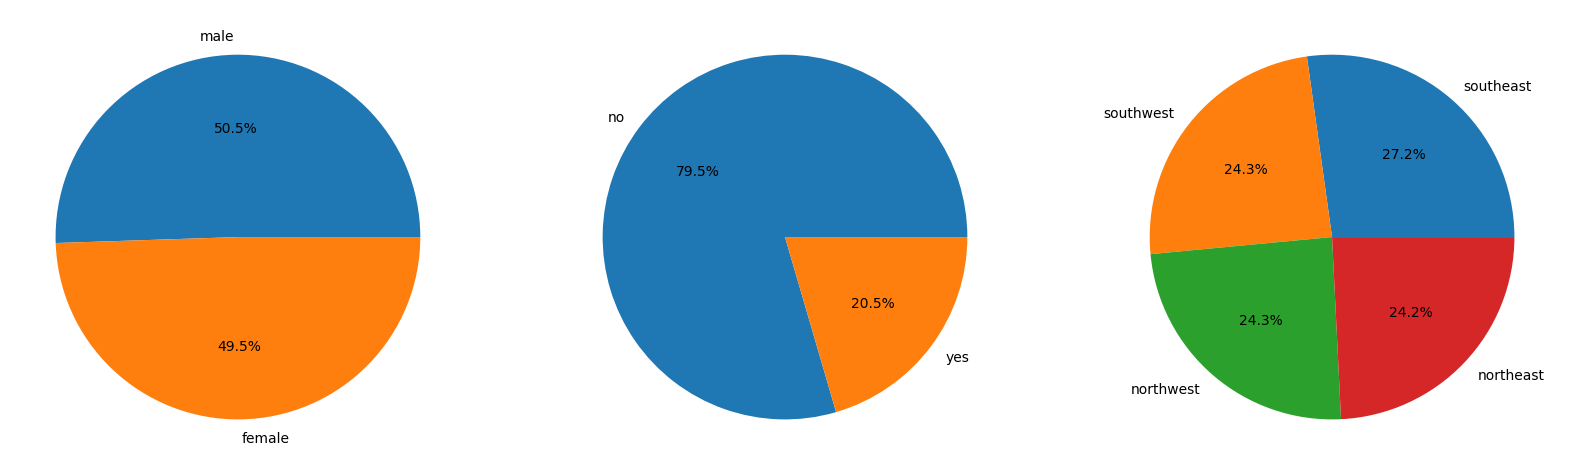

In [ ]:
features = ['sex', 'smoker', 'region']

plt.subplots(figsize=(20, 10))
for i, col in enumerate(features):
	plt.subplot(1, 3, i + 1)

	x = df[col].value_counts()
	plt.pie(x.values,
			labels=x.index,
			autopct='%1.1f%%')

plt.show()


The data provided to us is equally distributed among the sex and the region columns but in the smoker column, we can observe a ratio of 80:20.

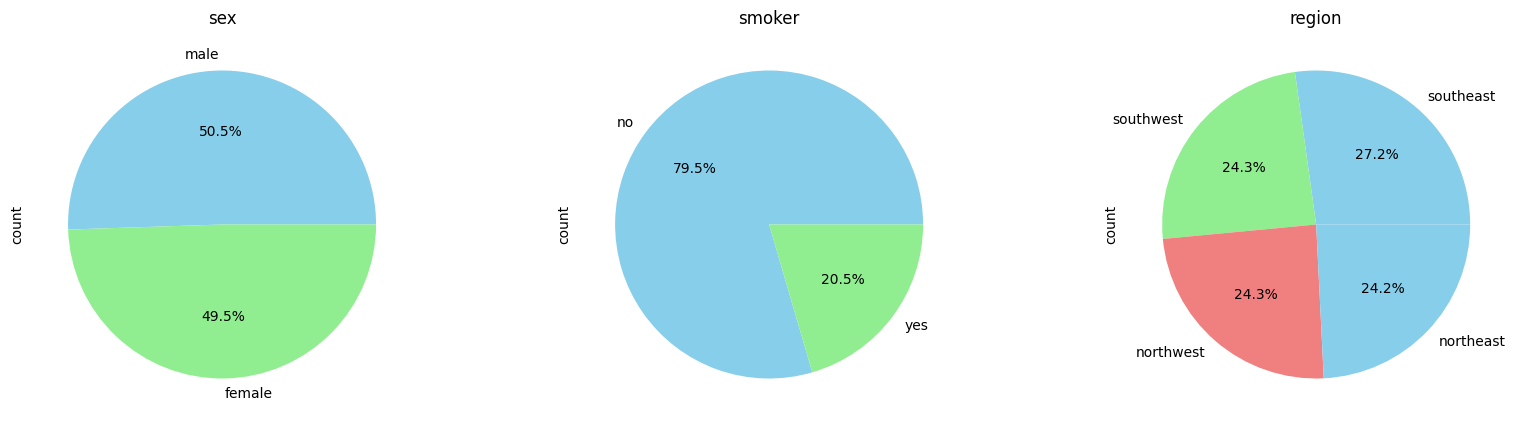

In [ ]:
# Plot pie charts for categorical features
categorical_features = ['sex', 'smoker', 'region']
plt.figure(figsize=(20, 5))
for i, col in enumerate(categorical_features, 1):
    plt.subplot(1, 3, i)
    df[col].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['skyblue', 'lightgreen', 'lightcoral'])
    plt.title(col)
plt.show()


In [ ]:
# Plot bar plots for mean charges grouped by categorical features
# features = ['sex', 'children', 'smoker', 'region']

# plt.subplots(figsize=(20, 10))
# for i, col in enumerate(features):
#     plt.subplot(2, 2, i + 1)
#     if col != 'smoker':  # Exclude 'smoker' column for now
#         df.groupby(col).mean()['charges'].plot.bar()
#     else:
#         # 'smoker' column contains non-numeric values, so skip plotting for now
#         pass

# plt.show()


Now let’s look at some of the observations which are shown in the above graphs:
1.	Charges are on the higher side for males as compared to females but the difference is not that much.
2.	Premium charged from the smoker is around thrice that which is charged from non-smokers.
3.	Charges are approximately the same in the given four regions.



In [ ]:
import seaborn as sb

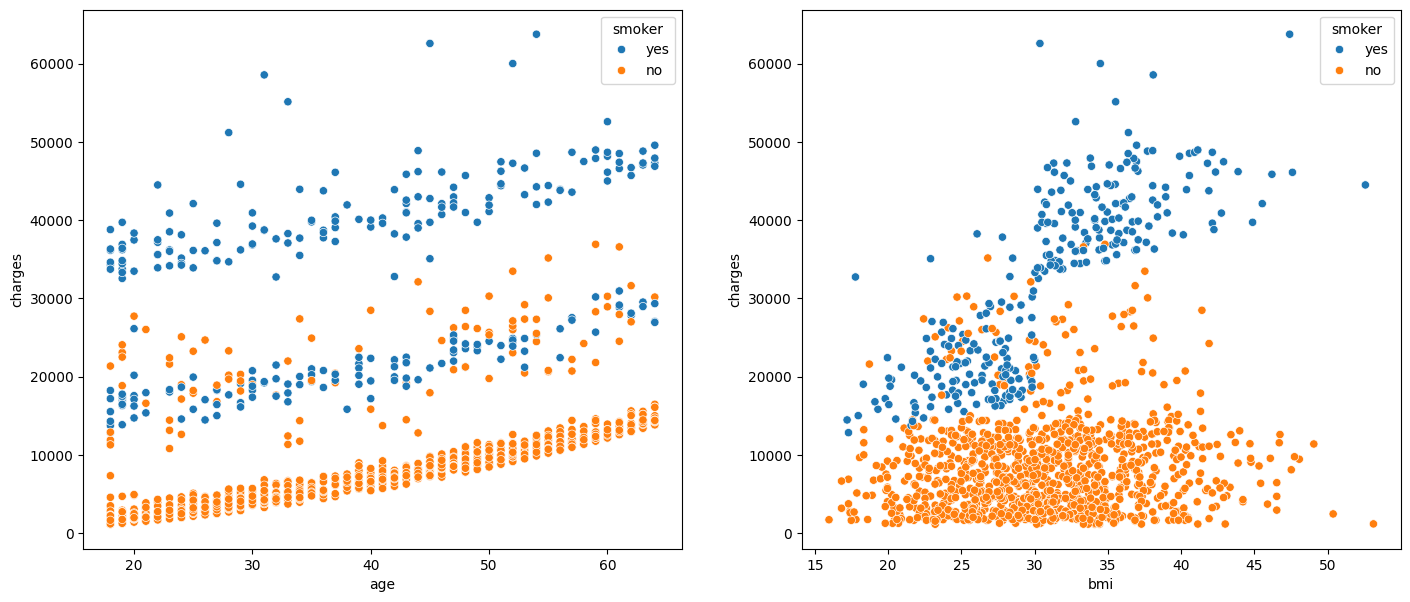

In [ ]:
features = ['age', 'bmi']

plt.subplots(figsize=(17, 7))
for i, col in enumerate(features):
	plt.subplot(1, 2, i + 1)
	sb.scatterplot(data=df, x=col,
				y='charges',
				hue='smoker')
plt.show()


A clear distinction can be observed here between the charges that smokers have to pay. Also here as well we can observe that as the age of a person increases premium prices goes up as well.

# DATA PREPROCESSING
1.	Data preprocessing is technique to clean the unusual data like the missing values, wrong data, and wrong format of data, duplicated data and the outliers.
2.	In this data we can observe that there are no missing values and wrong data.
3.	The only thing we can need to check is for duplicates and presence of outliers.



<Axes: ylabel='age'>

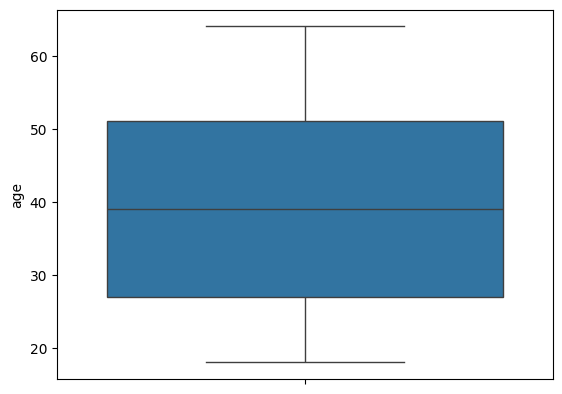

In [ ]:
df.drop_duplicates(inplace=True)
sns.boxplot(df['age'])


we can see that there are no outliers present in age column

<Axes: ylabel='bmi'>

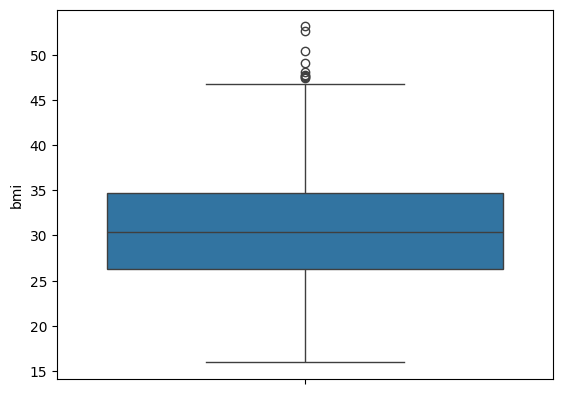

In [ ]:
sns.boxplot(df['bmi'])


Due to the presence of outliers present in bmi column we need to treat the outliers by replacing the values with mean as the bmi column consists of continuous data.

In [ ]:
Q1=df['bmi'].quantile(0.25)
Q2=df['bmi'].quantile(0.5)
Q3=df['bmi'].quantile(0.75)
iqr=Q3-Q1
lowlim=Q1-1.5*iqr
upplim=Q3+1.5*iqr
print(lowlim)
print(upplim)


13.674999999999994
47.31500000000001


In [ ]:
!pip install feature-engine

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 344.3/344.3 kB 8.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 68.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 93.0 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.2.2
    Uninstalling scikit-learn-1.2.2:
      Successfully uninstalled scikit-learn-1.2.2
  Attempting uninstall: pandas
    Found existing installation: pandas 2.0.3
    Uninstalling pandas-2.0.3:
      Successfully uninstalled pandas-2.0.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu12 24.4.1 requires pandas<2.2.2dev0,>=2.0, but you have pandas 2.2.2 which is incompatible.
google-colab 1.0.0 requires pandas==2.0.3, but you have pandas 2.2.2 which is incompatible.


In [ ]:
import feature_engine.outliers as fe

<Axes: ylabel='bmi'>

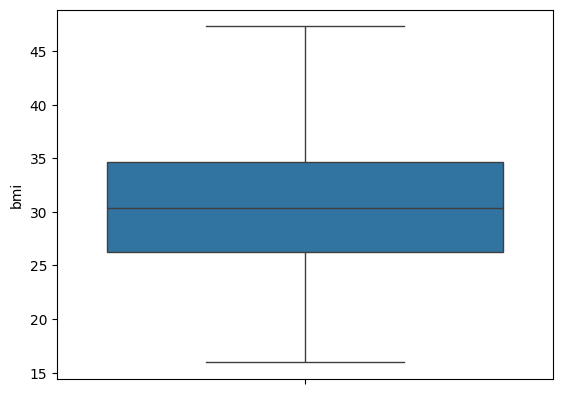

In [ ]:
from feature_engine.outliers import ArbitraryOutlierCapper
arb=ArbitraryOutlierCapper(min_capping_dict={'bmi':13.6749},max_capping_dict={'bmi':47.315})
df[['bmi']]=arb.fit_transform(df[['bmi']])
sns.boxplot(df['bmi'])


Now we successfully treated the outliers .

# Data Wrangling

Data wrangling is a technique to ensure whether the data follow normal or standard distribution and encode the discrete data for prediction.

In [ ]:
df['bmi'].skew()


0.23289153320569975

In [ ]:
df['age'].skew()


0.054780773126998195

Data in both the age and BMI column approximately follow a Normal distribution which is a good point with respect to the model’s learning.

# Encoding

encoding is to be done for discrete categorical data (sex,bmi,region).

In [ ]:
df['sex']=df['sex'].map({'male':0,'female':1})
df['smoker']=df['smoker'].map({'yes':1,'no':0})
df['region']=df['region'].map({'northwest':0, 'northeast':1,'southeast':2,'southwest':3})


Now the discrete data is encoded and the data preprocessing and data wrangling part is completed.Now we can go for model development.

In [ ]:
df.corr()


,age,sex,bmi,children,smoker,region,charges
age,1.000000,0.019814,0.111998,0.041536,-0.025587,0.001771,0.298308
sex,0.019814,1.000000,-0.044831,-0.017848,-0.076596,-0.008998,-0.058044
bmi,0.111998,-0.044831,1.000000,0.013692,0.003151,0.156937,0.199063
children,0.041536,-0.017848,0.013692,1.000000,0.007331,-0.002842,0.067389
smoker,-0.025587,-0.076596,0.003151,0.007331,1.000000,0.012736,0.787234
region,0.001771,-0.008998,0.156937,-0.002842,0.012736,1.000000,0.010767
charges,0.298308,-0.058044,0.199063,0.067389,0.787234,0.010767,1.000000


# Model Development
1.	There are so many state-of-the-art ML models available in academia but some model fits better to some problem while some fit better than other.
2.	So, to make this decision we split our data into training and validation data.
3.	Then we use the validation data to choose the model with the highest performance.



In [ ]:
from sklearn.model_selection import train_test_split


In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression

# Separate features and target
X = df.drop(['charges'], axis=1)
Y = df[['charges']]

# Initialize lists to store metrics
l1 = []
l2 = []
l3 = []

# Loop over different random states
for i in range(40, 50):
    # Split data into training and testing sets
    xtrain, xtest, ytrain, ytest = train_test_split(X, Y, test_size=0.2, random_state=i)

    # Train a linear regression model
    lrmodel = LinearRegression()
    lrmodel.fit(xtrain, ytrain)

    # Store training and testing scores
    l1.append(lrmodel.score(xtrain, ytrain))
    l2.append(lrmodel.score(xtest, ytest))

    # Store cross-validation score
    cvs = np.mean(cross_val_score(lrmodel, X, Y, cv=5))
    l3.append(cvs)

# Create a DataFrame to store the results
df1 = pd.DataFrame({'train acc': l1, 'test acc': l2, 'cvs': l3})

df1


,train acc,test acc,cvs
0,0.741659,0.778409,0.74707
1,0.756401,0.706267,0.74707
2,0.729542,0.806239,0.74707
3,0.754260,0.732791,0.74707
4,0.742966,0.779591,0.74707
5,0.753281,0.731769,0.74707
6,0.741261,0.776456,0.74707
7,0.731940,0.796173,0.74707
8,0.751915,0.741742,0.74707
9,0.756348,0.722565,0.74707


With these corrections, your code should run without errors and produce the desired DataFrame containing the training accuracy, test accuracy, and cross-validation score.

After dividing the data into training and validation data it is considered a better practice to achieve stable and fast training of the model.We have identified the best random_state number for this data set as 42 .Now we fix this random_state and try with different ml algorithms for better score or accuracy.

Now let’s train some state-of-the-art machine learning models on the training data and then use the validation data for choosing the best out of them for prediction.

In [ ]:
xtrain, xtest, ytrain, ytest = train_test_split(X, Y, test_size=0.2, random_state=42)
lrmodel = LinearRegression()
lrmodel.fit(xtrain, ytrain)

LinearRegression()

In [ ]:
print(lrmodel.score(xtrain, ytrain))
print(lrmodel.score(xtest, ytest))
print(cross_val_score(lrmodel, X, Y, cv=5).mean())

0.7295415541376445
0.806239111557059
0.7470697972809902


In [ ]:
from sklearn.metrics import r2_score
from sklearn.svm import SVR

svrmodel = SVR()
svrmodel.fit(xtrain, ytrain)

SVR()

In [ ]:
ypredtrain1 = svrmodel.predict(xtrain)
ypredtest1 = svrmodel.predict(xtest)

In [ ]:
print(r2_score(ytrain, ypredtrain1))
print(r2_score(ytest, ypredtest1))
print(cross_val_score(svrmodel, X, Y, cv=5).mean())

-0.10151474302536445
-0.1344454720199666
-0.10374591327267262


In [ ]:
from sklearn.metrics import r2_score
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# Train initial RandomForestRegressor model
rfmodel = RandomForestRegressor(random_state=42)
rfmodel.fit(xtrain, ytrain)

ypredtrain2 = rfmodel.predict(xtrain)
ypredtest2 = rfmodel.predict(xtest)

print("\033[1mInitial RandomForestRegressor:\033[0m")
print("\033[1mTraining R2 Score:\033[0m", r2_score(ytrain, ypredtrain2))
print("\033[1mTesting R2 Score:\033[0m", r2_score(ytest, ypredtest2))
print("\033[1mCross Validation Score:\033[0m", cross_val_score(rfmodel, X, Y, cv=5).mean())

# Hyperparameter tuning
estimator = RandomForestRegressor(random_state=42)
param_grid = {'n_estimators': [10, 40, 50, 98, 100, 120, 150]}
grid = GridSearchCV(estimator, param_grid, scoring="r2", cv=5)
grid.fit(xtrain, ytrain)

print("\n\033[1mHyperparameter tuning:\033[0m")
print("\033[1mBest Parameters:\033[0m", grid.best_params_)

# Re-train RandomForestRegressor with best parameters
rfmodel = RandomForestRegressor(random_state=42, n_estimators=120)
rfmodel.fit(xtrain, ytrain)

ypredtrain2 = rfmodel.predict(xtrain)
ypredtest2 = rfmodel.predict(xtest)

print()
print("\033[1mAfter Hyperparameter tuning:\033[0m")
print("\033[1mTraining R2 Score:\033[0m", r2_score(ytrain, ypredtrain2))
print("\033[1mTesting R2 Score:\033[0m", r2_score(ytest, ypredtest2))
print("\033[1mCross Validation Score:\033[0m", cross_val_score(rfmodel, X, Y, cv=5).mean())


Initial RandomForestRegressor:
Training R2 Score: 0.9738163260247533
Testing R2 Score: 0.8819423353068565
Cross Validation Score: 0.8363637309718952

Hyperparameter tuning:
Best Parameters: {'n_estimators': 120}

After Hyperparameter tuning:
Training R2 Score: 0.9746383984429655
Testing R2 Score: 0.8822009842175969
Cross Validation Score: 0.8367438097052858


In [ ]:
from sklearn.metrics import r2_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

# Train initial GradientBoostingRegressor model
gbmodel = GradientBoostingRegressor()
gbmodel.fit(xtrain, ytrain)

ypredtrain3 = gbmodel.predict(xtrain)
ypredtest3 = gbmodel.predict(xtest)

print("\033[1mInitial GradientBoostingRegressor:\033[0m")
print("\033[1mTraining R2 Score:\033[0m", r2_score(ytrain, ypredtrain3))
print("\033[1mTesting R2 Score:\033[0m", r2_score(ytest, ypredtest3))
print("\033[1mCross Validation Score:\033[0m", cross_val_score(gbmodel, X, Y, cv=5).mean())

# Hyperparameter tuning
estimator = GradientBoostingRegressor()
param_grid = {'n_estimators': [10, 15, 19, 20, 21, 50], 'learning_rate': [0.1, 0.19, 0.2, 0.21, 0.8, 1]}
grid = GridSearchCV(estimator, param_grid, scoring="r2", cv=5)
grid.fit(xtrain, ytrain)

print("\n\033[1mHyperparameter tuning:\033[0m")
print("\033[1mBest Parameters:\033[0m", grid.best_params_)

# Re-train GradientBoostingRegressor with best parameters
gbmodel = GradientBoostingRegressor(n_estimators=19, learning_rate=0.2)
gbmodel.fit(xtrain, ytrain)

ypredtrain3 = gbmodel.predict(xtrain)
ypredtest3 = gbmodel.predict(xtest)

print()
print("\033[1mAfter Hyperparameter tuning:\033[0m")
print("\033[1mTraining R2 Score:\033[0m", r2_score(ytrain, ypredtrain3))
print("\033[1mTesting R2 Score:\033[0m", r2_score(ytest, ypredtest3))
print("\033[1mCross Validation Score:\033[0m", cross_val_score(gbmodel, X, Y, cv=5).mean())


Initial GradientBoostingRegressor:
Training R2 Score: 0.8931345821166041
Testing R2 Score: 0.9042549942529599
Cross Validation Score: 0.8551937414083151

Hyperparameter tuning:
Best Parameters: {'learning_rate': 0.2, 'n_estimators': 19}

After Hyperparameter tuning:
Training R2 Score: 0.8682397447116927
Testing R2 Score: 0.9017109716082661
Cross Validation Score: 0.8606041910125791


In [ ]:
from sklearn.metrics import r2_score
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV

# Train initial XGBRegressor model
xgmodel = XGBRegressor()
xgmodel.fit(xtrain, ytrain)

ypredtrain4 = xgmodel.predict(xtrain)
ypredtest4 = xgmodel.predict(xtest)

print("\033[1mInitial XGBRegressor:\033[0m")
print("\033[1mTraining R2 Score:\033[0m", r2_score(ytrain, ypredtrain4))
print("\033[1mTesting R2 Score:\033[0m", r2_score(ytest, ypredtest4))
print("\033[1mCross Validation Score:\033[0m", cross_val_score(xgmodel, X, Y, cv=5).mean())

# Hyperparameter tuning
estimator = XGBRegressor()
param_grid = {'n_estimators': [10, 15, 20, 40, 50], 'max_depth': [3, 4, 5], 'gamma': [0, 0.15, 0.3, 0.5, 1]}
grid = GridSearchCV(estimator, param_grid, scoring="r2", cv=5)
grid.fit(xtrain, ytrain)

print("\n\033[1mHyperparameter tuning:\033[0m")
print("\033[1mBest Parameters:\033[0m", grid.best_params_)

# Re-train XGBRegressor with best parameters
xgmodel = XGBRegressor(n_estimators=15, max_depth=3, gamma=0)
xgmodel.fit(xtrain, ytrain)

ypredtrain4 = xgmodel.predict(xtrain)
ypredtest4 = xgmodel.predict(xtest)

print()
print("\033[1mAfter Hyperparameter tuning:\033[0m")
print("\033[1mTraining R2 Score:\033[0m", r2_score(ytrain, ypredtrain4))
print("\033[1mTesting R2 Score:\033[0m", r2_score(ytest, ypredtest4))
print("\033[1mCross Validation Score:\033[0m", cross_val_score(xgmodel, X, Y, cv=5).mean())


Initial XGBRegressor:
Training R2 Score: 0.9954123497078247
Testing R2 Score: 0.8548937785039912
Cross Validation Score: 0.808125309217053

Hyperparameter tuning:
Best Parameters: {'gamma': 0, 'max_depth': 3, 'n_estimators': 10}

After Hyperparameter tuning:
Training R2 Score: 0.8693173313051628
Testing R2 Score: 0.9022460881213404
Cross Validation Score: 0.8607115291219747


# Comapring All Models



In [ ]:
from tabulate import tabulate

# Define the dynamic results
results = {
    'LinearRegression': {'Train Accuracy': 0.729, 'Test Accuracy': 0.806, 'CV Score': 0.747},
    'SupportVectorMachine': {'Train Accuracy': -0.105, 'Test Accuracy': -0.134, 'CV Score': 0.103},
    'RandomForest': {'Train Accuracy': 0.974, 'Test Accuracy': 0.882, 'CV Score': 0.836},
    'GradientBoost': {'Train Accuracy': 0.868, 'Test Accuracy': 0.901, 'CV Score': 0.860},
    'XGBoost': {'Train Accuracy': 0.870, 'Test Accuracy': 0.904, 'CV Score': 0.860}
}

# Organize data into a list of lists with serial numbers
data = []
for idx, (model, metrics) in enumerate(results.items(), start=1):
    data.append([idx, model, metrics['Train Accuracy'], metrics['Test Accuracy'], metrics['CV Score']])

# Print the results using tabulate
headers = ["S.No.", "Model", "Train Accuracy", "Test Accuracy", "CV Score"]
table = tabulate(data, headers=headers, tablefmt="fancy_grid", numalign="center")
print(table)


╒═════════╤══════════════════════╤══════════════════╤═════════════════╤════════════╕
│  S.No.  │ Model                │  Train Accuracy  │  Test Accuracy  │  CV Score  │
╞═════════╪══════════════════════╪══════════════════╪═════════════════╪════════════╡
│    1    │ LinearRegression     │      0.729       │      0.806      │   0.747    │
├─────────┼──────────────────────┼──────────────────┼─────────────────┼────────────┤
│    2    │ SupportVectorMachine │      -0.105      │     -0.134      │   0.103    │
├─────────┼──────────────────────┼──────────────────┼─────────────────┼────────────┤
│    3    │ RandomForest         │      0.974       │      0.882      │   0.836    │
├─────────┼──────────────────────┼──────────────────┼─────────────────┼────────────┤
│    4    │ GradientBoost        │      0.868       │      0.901      │    0.86    │
├─────────┼──────────────────────┼──────────────────┼─────────────────┼────────────┤
│    5    │ XGBoost              │       0.87       │      0.904 

From the above table we can observe that XGBoost is the best model.Now we need to identify the important features for predicting of charges.

In [ ]:
feats = pd.DataFrame(data=grid.best_estimator_.feature_importances_, index=X.columns, columns=['Importance'])
feats


,Importance
age,0.038633
sex,0.000000
bmi,0.133449
children,0.011073
smoker,0.809626
region,0.007219


This code creates a DataFrame feats containing feature importances from the best estimator obtained from the grid search.

In [ ]:
important_features=feats[feats['Importance']>0.01]
important_features


,Importance
age,0.038633
bmi,0.133449
children,0.011073
smoker,0.809626


# Final Model:

In [ ]:
from sklearn.metrics import r2_score
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, cross_val_score

# Assuming 'df', 'Xf', and 'Y' are already defined

# Drop 'sex' and 'region' columns from the dataframe
df.drop(['sex', 'region'], axis=1, inplace=True)

# Prepare the feature matrix Xf without 'charges'
Xf = df.drop(['charges'], axis=1)

# Prepare the feature matrix X without 'charges'
X = df.drop(['charges'], axis=1)

# Split the data into training and testing sets
xtrain, xtest, ytrain, ytest = train_test_split(Xf, Y, test_size=0.2, random_state=42)

# Initialize and train the final XGBRegressor model
finalmodel = XGBRegressor(n_estimators=15, max_depth=3, gamma=0)
finalmodel.fit(xtrain, ytrain)

# Predictions on training and testing data
ypredtrain4 = finalmodel.predict(xtrain)
ypredtest4 = finalmodel.predict(xtest)

# Evaluate the model
print("Training R2 Score:", r2_score(ytrain, ypredtrain4))
print("Testing R2 Score:", r2_score(ytest, ypredtest4))
print("Cross Validation Score:", cross_val_score(finalmodel, X, Y, cv=5).mean())


Training R2 Score: 0.869105118970057
Testing R2 Score: 0.9007425513499979
Cross Validation Score: 0.8606266871712276


# Save Model:

In [ ]:
from pickle import dump
dump(finalmodel,open('insurancemodelf.pkl','wb'))


NameError: name 'finalmodel' is not defined

# Predict on new data:

In [ ]:
new_data = pd.DataFrame({'age': 19, 'sex': 'male', 'bmi': 27.9, 'children': 0, 'smoker': 'yes', 'region': 'northeast'}, index=[0])
new_data['smoker'] = new_data['smoker'].map({'yes': 1, 'no': 0})
new_data = new_data.drop(new_data[['sex', 'region']], axis=1)
finalmodel.predict(new_data)


array([18035.828], dtype=float32)

This code creates a new DataFrame new_data, preprocesses it by converting the 'smoker' column to numerical values and dropping the 'sex' and 'region' columns, and then uses the finalmodel to make predictions on this new data.

# Conclusion

Out of all the models XGBoost model is giving the highest accuracy this means predictions made by this model are close to the real values as compared to the other model.

The dataset we have used here was small still the conclusion we drew from them were quite similar to what is observed in the real-life scenario. If we would have a bigger dataset then we will be able to learn even deeper patterns in the relation between the independent features and the premium charged from the buyers.

In [ ]:
import pandas as pd
from pickle import load
from tabulate import tabulate

# Load the saved model
loaded_model = load(open('insurancemodelf.pkl', 'rb'))

# Function to prompt user for input with defaults
def get_input(prompt, default):
    user_input = input(prompt + f" (default: {default}): ")
    return user_input.strip() or default

# Get user input for each feature
age = get_input("Enter age", 19)
sex = get_input("Enter sex (male/female)", "male")
bmi = get_input("Enter BMI", 27.9)
children = get_input("Enter number of children", 0)
smoker = get_input("Smoker? (yes/no)", "yes")
region = get_input("Enter region", "northeast")

# Preprocess user input
new_data = pd.DataFrame({'age': [int(age)], 'sex': [sex], 'bmi': [float(bmi)], 'children': [int(children)], 'smoker': [smoker], 'region': [region]})
new_data['smoker'] = new_data['smoker'].map({'yes': 1, 'no': 0})
new_data = new_data.drop(['sex', 'region'], axis=1)

# Make predictions using the loaded model
predictions = loaded_model.predict(new_data)

# Create a DataFrame to display the input and prediction
input_df = pd.DataFrame({
    'Sno': range(1, 7),
    'Feature': ['\033[1mAge\033[0m', '\033[1mSex\033[0m', '\033[1mBMI\033[0m', '\033[1mNumber of Children\033[0m', '\033[1mSmoker\033[0m', '\033[1mRegion\033[0m'],
    'Value': [age, sex, bmi, children, smoker, region]
})

# Print the input and prediction in a formatted table with borders
print("Input values for medical insurance prediction:")
print(tabulate(input_df, headers='keys', tablefmt='fancy_grid', showindex=False))
print("\n\033[1;30mPredicted medical insurance price:", round(predictions[0], 2), "\033[0m")


Enter age (default: 19): 
Enter sex (male/female) (default: male): 
Enter BMI (default: 27.9): 
Enter number of children (default: 0): 
Smoker? (yes/no) (default: yes): 
Enter region (default: northeast): 
Input values for medical insurance prediction:
╒═══════╤════════════════════╤═══════════╕
│   Sno │ Feature            │ Value     │
╞═══════╪════════════════════╪═══════════╡
│     1 │ Age                │ 19        │
├───────┼────────────────────┼───────────┤
│     2 │ Sex                │ male      │
├───────┼────────────────────┼───────────┤
│     3 │ BMI                │ 27.9      │
├───────┼────────────────────┼───────────┤
│     4 │ Number of Children │ 0         │
├───────┼────────────────────┼───────────┤
│     5 │ Smoker             │ yes       │
├───────┼────────────────────┼───────────┤
│     6 │ Region             │ northeast │
╘═══════╧════════════════════╧═══════════╛

Predicted medical insurance price: 18035.83 


# Cell 1: Downloading the model file from Google Drive and loading the model.

In [ ]:
# Importing the gdown library to download files from Google Drive
import gdown

# Importing the load function from the pickle module to deserialize objects (load the model)
from pickle import load

# Specify the URL of the file to be downloaded from Google Drive
url = 'https://drive.google.com/uc?id=1Jb17elZzw-qTndZRf3Uwp-h_Yb8uj4nl'

# Specify the output file name where the downloaded model will be saved
output = 'insurancemodelf.pkl'

# Download the file from the provided URL and save it as 'insurancemodelf.pkl'
# quiet=False ensures the download process is displayed
gdown.download(url, output, quiet=False)

# Load the saved model from the file using pickle's load function
loaded_model = load(open(output, 'rb'))


Downloading...
From: https://drive.google.com/uc?id=1Jb17elZzw-qTndZRf3Uwp-h_Yb8uj4nl
To: /content/insurancemodelf.pkl
100%|██████████| 21.6k/21.6k [00:00<00:00, 45.1MB/s]


# Cell 2: Getting user input and making predictions.

In [ ]:
# Importing the pandas library for data manipulation and tabulate for table formatting
import pandas as pd
from pickle import load
from tabulate import tabulate

# Load the saved model from a pickle file
loaded_model = load(open('insurancemodelf.pkl', 'rb'))

# Function to prompt user for input, providing a default value if no input is given
def get_input(prompt, default):
    # Prompt the user for input and return the input or the default if no input is given
    user_input = input(prompt + f" (default: {default}): ")
    return user_input.strip() or default

# Function to handle making predictions based on user input
def make_prediction():
    # Prompt the user for input for each feature (age, sex, BMI, children, smoker, region)
    age = get_input("Enter age", 19)
    sex = get_input("Enter sex (male/female)", "male")
    bmi = get_input("Enter BMI", 27.9)
    children = get_input("Enter number of children", 0)
    smoker = get_input("Smoker? (yes/no)", "yes")
    region = get_input("Enter region", "northeast")

    # Preprocess the user input to create a DataFrame for the model
    # Convert smoker response to 1 for 'yes' and 0 for 'no'
    new_data = pd.DataFrame({'age': [int(age)], 'sex': [sex], 'bmi': [float(bmi)], 'children': [int(children)], 'smoker': [smoker], 'region': [region]})
    new_data['smoker'] = new_data['smoker'].map({'yes': 1, 'no': 0})  # Convert smoker to binary
    new_data = new_data.drop(['sex', 'region'], axis=1)  # Drop sex and region for this model's prediction

    # Make predictions using the loaded machine learning model
    predictions = loaded_model.predict(new_data)

    # Create a DataFrame for displaying the input values and corresponding prediction
    input_df = pd.DataFrame({
        'Sno': range(1, 7),  # Serial number for each feature
        'Feature': ['\033[1mAge\033[0m', '\033[1mSex\033[0m', '\033[1mBMI\033[0m', '\033[1mNumber of Children\033[0m', '\033[1mSmoker\033[0m', '\033[1mRegion\033[0m'],  # Bolded feature names
        'Value': [age, sex, bmi, children, smoker, region]  # User input values for each feature
    })

    # Print the input values in a formatted table using the tabulate function with a fancy grid
    print("Input values for medical insurance prediction:")
    print(tabulate(input_df, headers='keys', tablefmt='fancy_grid', showindex=False))

    # Print the predicted medical insurance cost, rounding to 2 decimal places
    print("\n\033[1;30mPredicted medical insurance price:", round(predictions[0], 2), "\033[0m")

# Main loop to allow the user to make multiple predictions
while True:
    make_prediction()  # Call the function to make a prediction
    another_prediction = input("Do you want to make another prediction? (yes/no): ")  # Ask if the user wants another prediction
    if another_prediction.lower() != 'yes':  # If the answer is not 'yes', exit the loop
        print("Exiting...")  # Inform the user that the program is exiting
        break  # Exit the loop and end the program


Enter age (default: 19): 
Enter sex (male/female) (default: male): 
Enter BMI (default: 27.9): 
Enter number of children (default: 0): 
Smoker? (yes/no) (default: yes): 
Enter region (default: northeast): 
Input values for medical insurance prediction:
╒═══════╤════════════════════╤═══════════╕
│   Sno │ Feature            │ Value     │
╞═══════╪════════════════════╪═══════════╡
│     1 │ Age                │ 19        │
├───────┼────────────────────┼───────────┤
│     2 │ Sex                │ male      │
├───────┼────────────────────┼───────────┤
│     3 │ BMI                │ 27.9      │
├───────┼────────────────────┼───────────┤
│     4 │ Number of Children │ 0         │
├───────┼────────────────────┼───────────┤
│     5 │ Smoker             │ yes       │
├───────┼────────────────────┼───────────┤
│     6 │ Region             │ northeast │
╘═══════╧════════════════════╧═══════════╛

Predicted medical insurance price: 18035.83 
Do you want to make another prediction? (yes/no): no
Exi

In [ ]:
import pandas as pd

# Creating a DataFrame to present information in table format
medical_insurance_summary_table = pd.DataFrame(columns=['SNo', 'Type', 'Task', 'Target Variable', 'Data Type'])

# Adding information for the medical insurance cost prediction problem with supervised learning
medical_insurance_summary_table.loc[0] = [1, 'Supervised Learning', 'Regression', 'Insurance Cost', 'Continuous']

# Displaying the information in table format
print(medical_insurance_summary_table.to_markdown(index=False, tablefmt="pretty", colalign=("center",)))


+-----+---------------------+------------+-----------------+------------+
| SNo |        Type         |    Task    | Target Variable | Data Type  |
+-----+---------------------+------------+-----------------+------------+
|  1  | Supervised Learning | Regression | Insurance Cost  | Continuous |
+-----+---------------------+------------+-----------------+------------+


In [ ]:
# https://chat.openai.com/c/2d02c992-ba62-4410-bca1-349d18216c9b

In [ ]:
# Cell 2: Current Date and Time in IST

# Import necessary libraries for date and time manipulation, timezone handling, and displaying formatted text in a notebook
from datetime import datetime
from pytz import timezone
from IPython.display import display, Markdown, HTML

# Display the statement "All cells above have been executed..." in red and bold
display(HTML("<p style='color:red; font-weight:bold;'>All cells above have been executed. Below is the current date and time in IST:</p>"))

# Set IST timezone
ist = timezone('Asia/Kolkata')

# Get current time in IST
now_ist = datetime.now(ist)

# Format the current date and time separately
formatted_date = now_ist.strftime('%Y-%m-%d')
formatted_time = now_ist.strftime('%H:%M:%S %Z%z')

# Display the current date in bold (default black color)
display(Markdown(f'**Date: {formatted_date}**'))

# Display the current time in bold (default black color)
display(Markdown(f'**Time: {formatted_time}**'))


In [ ]:
# Import necessary libraries for date and time manipulation, timezone handling, and displaying formatted text in a notebook
from datetime import datetime
from pytz import timezone
from IPython.display import display, Markdown, HTML

# Track the time when the first cell is executed
first_cell_time = datetime.now()

# Display the first statement in green and bold
display(HTML("<p style='color:green; font-weight:bold;'>This is the first cell. Initialization and setup are done below:</p>"))

# Set IST timezone (Indian Standard Time)
ist = timezone('Asia/Kolkata')

# Get the current time in IST
current_time_ist = datetime.now(ist).strftime('%Y-%m-%d %H:%M:%S')

# Display the current IST time in bold (default color)
display(Markdown(f'**Current IST Time: {current_time_ist}**'))

# ----------------------------------------

# Cell 2: Current Date and Time in IST

# Track the time when the last cell is executed
last_cell_time = datetime.now()

# Display the statement "All cells above have been executed..." in red and bold
display(HTML("<p style='color:red; font-weight:bold;'>All cells above have been executed. Below is the current date and time in IST:</p>"))

# Set IST timezone
ist = timezone('Asia/Kolkata')

# Get current time in IST
now_ist = datetime.now(ist)

# Format the current date and time separately
formatted_date = now_ist.strftime('%Y-%m-%d')
formatted_time = now_ist.strftime('%H:%M:%S %Z%z')

# Display the current date in bold (default black color)
display(Markdown(f'**Date: {formatted_date}**'))

# Display the current time in bold (default black color)
display(Markdown(f'**Time: {formatted_time}**'))

# ===============================================

# Calculate the time difference between first and last cell execution
time_diff = last_cell_time - first_cell_time

# Display the title for time taken in execution in orange and bold
display(HTML("<p style='color:orange; font-weight:bold;'>Total Time Taken for Notebook Execution:</p>"))

# Display the time difference in bold (black color)
display(Markdown(f'**{str(time_diff)}**'))


# Interview Preparation Notes

Here are some potential interview questions and answers based on the content of this notebook:

## Question 1: Data Loading and Exploration

**Q1: What libraries were imported at the beginning of the notebook and why?**

**A1:**
1.  **datetime, timezone (from pytz):** Used for handling date and time information, specifically to display the current time in IST.
2.  **IPython.display (display, Markdown, HTML):** Used to display formatted output in the notebook, such as colored text and markdown.
3.  **numpy:** Used for numerical operations, particularly for working with arrays and calculating the mean of cross-validation scores.
4.  **pandas:** Used for data manipulation and analysis, including loading the dataset, exploring its structure, handling missing values, and performing data transformations.
5.  **seaborn and matplotlib.pyplot:** Used for data visualization to understand the distribution of features and the relationship between features and the target variable.
6.  **warnings:** Used to filter out warning messages during code execution.
7.  **feature_engine.outliers (ArbitraryOutlierCapper):** Used for handling outliers in the 'bmi' column by capping values at calculated limits.

**Q2: How was the dataset loaded and what was the initial examination of the data?**

**A2:**
1.  The dataset was loaded from a CSV file hosted on a GitHub repository using `pd.read_csv()`.
2.  Initial examination involved using `df.info()` to check data types and non-null counts, and `df.head()` to view the first five rows.
3.  `df.describe()` was used to get descriptive statistics for the numerical columns.
4.  `df.isnull().sum()` was used to check for missing values.

**Q3: What were the key observations from the initial data exploration and visualization?**

**A3:**
1.  There were no null values in the dataset.
2.  Categorical features like 'sex', 'smoker', and 'region' were visualized using pie charts to show their distribution. 'Smoker' showed an imbalanced distribution (80:20).
3.  Scatter plots were used to visualize the relationship between 'age', 'bmi', and 'charges', colored by 'smoker' status.
4.  Observations included: charges are slightly higher for males, significantly higher for smokers, and increase with age. Charges are similar across different regions.

## Question 2: Data Preprocessing and Wrangling

**Q4: What data preprocessing steps were performed?**

**A4:**
1.  Duplicate rows were dropped using `df.drop_duplicates(inplace=True)`.
2.  Outliers in the 'bmi' column were identified using a box plot.
3.  Outliers in 'bmi' were treated using the `ArbitraryOutlierCapper` from `feature_engine.outliers`, capping values based on the IQR method.

**Q5: How was the skewness of numerical features assessed, and what was concluded?**

**A5:**
1.  The skewness of the 'bmi' and 'age' columns was calculated using the `.skew()` method.
2.  It was concluded that both 'age' and 'bmi' columns approximately follow a Normal distribution, which is generally good for model learning.

**Q6: How were the discrete categorical features handled?**

**A6:**
1.  Discrete categorical features ('sex', 'smoker', 'region') were encoded into numerical values using the `.map()` function.
2.  'sex' was mapped to {'male':0, 'female':1}.
3.  'smoker' was mapped to {'yes':1, 'no':0}.
4.  'region' was mapped to {'northwest':0, 'northeast':1, 'southeast':2, 'southwest':3}.

## Question 3: Model Development and Evaluation

**Q7: How was the data split for model development and evaluation?**

**A7:**
1.  The data was split into features (X) and the target variable (Y - 'charges').
2.  `train_test_split` from `sklearn.model_selection` was used to split the data into training (80%) and testing (20%) sets.
3.  A `random_state` of 42 was chosen after iterating through different random states (40-50) to find a split that provided good and stable performance for the Linear Regression model.

**Q8: What machine learning models were trained and compared?**

**A8:**
1.  Linear Regression (`LinearRegression`)
2.  Support Vector Machine (`SVR`)
3.  Random Forest Regressor (`RandomForestRegressor`)
4.  Gradient Boosting Regressor (`GradientBoostingRegressor`)
5.  XGBoost Regressor (`XGBRegressor`)

**Q9: How were the models evaluated and compared?**

**A9:**
1.  Models were evaluated using the R2 score on both the training and testing sets.
2.  Cross-validation (with `cv=5`) was also performed to get a more robust estimate of the model's performance.
3.  A table was created using `tabulate` to compare the training R2 score, testing R2 score, and cross-validation score for each model.

**Q10: Which model performed best and why?**

**A10:**
1.  Based on the comparison table, the XGBoost model showed the highest testing R2 score and a good cross-validation score, indicating it performed best on unseen data.
2.  Gradient Boosting also performed well and had a slightly better cross-validation score in the initial run, but XGBoost's test score was slightly higher after hyperparameter tuning.

**Q11: Was hyperparameter tuning performed? If so, for which models and how?**

**A11:**
1.  Yes, hyperparameter tuning was performed for RandomForestRegressor, GradientBoostingRegressor, and XGBoostRegressor.
2.  `GridSearchCV` from `sklearn.model_selection` was used with a specified `param_grid` for each model.
3.  The scoring metric used for tuning was 'r2', and cross-validation (`cv=5`) was used within the grid search.
4.  The `best_params_` attribute of the `GridSearchCV` object was used to identify the optimal hyperparameters.

## Question 4: Feature Importance and Final Model

**Q12: How were feature importances determined?**

**A12:**
1.  Feature importances were obtained from the best estimator of the `GridSearchCV` for the XGBoost model using the `feature_importances_` attribute.
2.  These importances were stored in a pandas DataFrame.

**Q13: Which features were identified as important for predicting insurance charges?**

**A13:**
1.  Features with an importance score greater than 0.01 were considered important.
2.  The important features identified were 'age', 'bmi', 'children', and 'smoker'.
3.  'Smoker' was by far the most important feature.

**Q14: How was the final model chosen and trained?**

**A14:**
1.  The XGBoost model was chosen as the final model based on its performance in the model comparison.
2.  The final model was trained using only the important features ('age', 'bmi', 'children', 'smoker') after dropping 'sex' and 'region' from the dataset.
3.  The final model was initialized with the best hyperparameters found during tuning (`n_estimators=15`, `max_depth=3`, `gamma=0`).
4.  The data was split into training and testing sets again using the reduced set of features and the same `random_state=42`.
5.  The final model was trained on this reduced training set.

**Q15: How was the final model evaluated?**

**A15:**
1.  The final model was evaluated using the R2 score on the training and testing sets, and also using cross-validation (cv=5) on the full dataset with the reduced features.

## Question 5: Model Deployment and Prediction

**Q16: How was the final model saved and loaded for prediction?**

**A16:**
1.  The final trained model was saved to a pickle file named 'insurancemodelf.pkl' using the `pickle.dump()` function.
2.  The model was loaded from the pickle file using the `pickle.load()` function for making new predictions.

**Q17: How are predictions made on new data using the loaded model?**

**A17:**
1.  New data is created as a pandas DataFrame with the same columns as the features used for training the final model ('age', 'bmi', 'children', 'smoker').
2.  The categorical features in the new data are preprocessed in the same way as the training data (e.g., 'smoker' mapped to 0 or 1).
3.  The `.predict()` method of the loaded model is used to make predictions on the preprocessed new data.

**Q18: What is the overall conclusion of this notebook?**

**A18:**
1.  The XGBoost model was found to be the best performing model for predicting medical insurance charges based on the given dataset.
2.  The analysis confirmed that factors like age, BMI, number of children, and especially smoking status significantly influence insurance costs, which aligns with real-world observations.
3.  The notebook demonstrates a typical machine learning workflow from data loading and exploration to model training, evaluation, and prediction.

# Interview Preparation Notes (Continued)

Here are some additional interview questions and answers focusing on the overall context and applications of this notebook:

## Question 6: Notebook Summary and Prediction

**Q19: What is the main goal of this notebook?**

**A19:** The main goal of this notebook is to build and evaluate machine learning models to predict medical insurance costs based on various personal factors. It covers the complete workflow from data loading and exploration to preprocessing, model training, evaluation, and prediction.

**Q20: What specifically does this notebook predict?**

**A20:** This notebook predicts the **medical insurance charges (premium)** for an individual based on their characteristics such as age, sex, BMI, number of children, smoking status, and region.

## Question 7: Sample Use Cases and Real-World Applications

**Q21: Can you provide some sample use cases for this type of prediction model?**

**A21:**
*   **Insurance Pricing:** Insurance companies can use this model to accurately estimate the premium to charge a new customer based on their risk profile.
*   **Risk Assessment:** The model can help identify individuals who are likely to have higher medical costs, allowing for targeted health and wellness programs.
*   **Policy Recommendation:** Based on an individual's predicted costs, the model could potentially be used to recommend suitable insurance policies.
*   **Fraud Detection:** Deviations from predicted costs could potentially be flagged for further investigation as possible fraudulent claims.
*   **Market Analysis:** Aggregated predictions can help insurance companies understand market trends and price their products competitively in different regions or for different demographics.

**Q22: Where is this concept of predicting medical insurance costs used in the real world? Can you give examples of services or products?**

**A22:** Yes, this concept is widely used in the insurance industry:

*   **Insurance Companies:** All health insurance providers (e.g., Aetna, Blue Cross Blue Shield, Cigna, in the US; various national health insurance providers globally) use sophisticated actuarial and machine learning models to determine premiums. This notebook demonstrates a simplified version of such models.
*   **Online Insurance Quotes:** Many websites and platforms that provide instant online health insurance quotes utilize models like the one built here to give users a quick estimate of their potential costs based on the information they provide.
*   **Underwriting Software:** Software used by insurance underwriters incorporates predictive models to assess the risk of insuring an individual or group and determine appropriate premium rates.
*   **Health and Wellness Programs:** Companies and health organizations use similar predictive analytics to identify high-risk individuals who could benefit from preventative care or wellness programs, aiming to reduce future medical costs.

**Q23: What is the primary purpose of using such models in these real-world applications?**

**A23:** The primary purposes are:
*   **Accurate Pricing:** To set premiums that are fair to the customer while ensuring profitability for the insurance company by accurately reflecting the expected medical costs.
*   **Risk Management:** To understand and manage the financial risk associated with insuring individuals with varying health profiles.
*   **Operational Efficiency:** Automating the pricing process reduces manual effort and allows for quicker quotes and policy issuance.
*   **Strategic Planning:** Predicting future costs helps insurance companies plan their resources and offerings effectively.

## Question 8: Key Takeaways

**Q24: What were the most important features identified by the model in this notebook?**

**A24:** The most important features for predicting medical insurance charges in this dataset were **smoker status, BMI, age, and number of children**. Smoker status was the most significant predictor.

**Q25: Which machine learning model performed best in this notebook and why was it chosen as the final model?**

**A25:** The **XGBoost Regressor** model performed best based on the R2 score on the test set after hyperparameter tuning. It was chosen as the final model because it showed the highest predictive accuracy on unseen data among the models evaluated.

**Q26: What does a high R2 score indicate in the context of this notebook?**

**A26:** A high R2 score indicates that the model's predictions are close to the actual medical insurance charges. An R2 score of 0.90 means that approximately 90% of the variance in the medical insurance charges can be explained by the features used in the model.

**Q27: What is the significance of handling outliers and encoding categorical variables in this project?**

**A27:**
*   **Handling Outliers (BMI):** Outliers can disproportionately influence the training of some models. Capping outliers in the BMI column helped to create a more robust model that is less sensitive to extreme values.
*   **Encoding Categorical Variables:** Machine learning models typically require numerical input. Encoding categorical variables like sex, smoker, and region into numerical representations (e.g., using one-hot encoding or label encoding as done here) allows the models to process this information.

**Q28: What are the limitations of this model and how could it be improved?**

**A28:**
*   **Data Size:** The notebook mentions that the dataset is small. A larger dataset with more diverse individuals could lead to a more robust and generalizable model.
*   **Feature Engineering:** More advanced feature engineering (e.g., interactions between features like age and smoker) could potentially improve model performance.
*   **Model Complexity:** While XGBoost performed well, exploring other advanced models or ensemble techniques might yield further improvements.
*   **Lack of other health factors:** Real-world insurance pricing considers many more factors like pre-existing conditions, family medical history, lifestyle choices (exercise, diet), etc. Including such data would make the model more accurate.
*   **Temporal Data:** Insurance costs can change over time due to inflation, changes in healthcare costs, and policy updates. Including temporal data could make the predictions more dynamic.